# 6CS012 – Final Portfolio Assessment 2026
## Part II: Vision Task – Facial Expression Classification
**Herald College Kathmandu | University of Wolverhampton**

---
**Group:** Team A  
**Members:** Abhiral Pradhan, Srijal Giri, Prajwol Shrestha, Sadish Raj Pandey  
**Section:** L6CG12

---
### Speed Optimisations
| Technique | Why it helps |
|---|---|
| Unzip to local `/content/` SSD | Drive I/O is 5–10× slower than Colab's local disk |
| `tf.data` with `.cache()` | Images loaded from RAM from epoch 2 onward – zero disk reads |
| `.prefetch(AUTOTUNE)` | GPU never sits idle waiting for the next batch |
| `num_parallel_calls=AUTOTUNE` | Image decoding uses all CPU cores in parallel |
| Mixed precision `float16` | ~2× GPU throughput on T4/V100/A100 |
| Batch size 64 | Larger batches = fewer steps per epoch |

### Notebook Structure
- **Section 1** – Mount Drive & Unzip to Local SSD
- **Section 2** – Imports & Hyperparameters
- **Section 3** – Data Understanding & Visualization
- **Section 4** – Fast tf.data Pipeline
- **Section 5 (Part A)** – Baseline CNN from Scratch
- **Section 6 (Part A)** – Deeper CNN with Regularization
- **Section 7 (Part A)** – Experimentation & Comparative Analysis
- **Section 8 (Part B)** – Transfer Learning (MobileNetV2)

---
## Section 1: Mount Drive & Unzip Dataset to Local SSD

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import zipfile, os, time

# ── SET YOUR ZIP PATH HERE ────────────────────────────────────────
ZIP_PATH = '/content/drive/MyDrive/facial expression classification.zip'
# ─────────────────────────────────────────────────────────────────

EXTRACT_DIR = '/content/dataset'  # Local Colab SSD

if not os.path.exists(EXTRACT_DIR):
    print('Unzipping dataset to local SSD...')
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print(f'Unzip complete in {time.time()-t0:.1f}s')
else:
    print('Dataset already on local SSD – skipping unzip.')

# Auto-detect folder containing train/validation/test
def find_dataset(root):
    for dirpath, dirnames, _ in os.walk(root):
        if {'train', 'validation', 'test'}.issubset(set(dirnames)):
            return dirpath
    return None

BASE_DIR  = find_dataset(EXTRACT_DIR)
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'validation')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

assert os.path.exists(TRAIN_DIR), f'train folder not found at {TRAIN_DIR}'
assert os.path.exists(VAL_DIR),   f'validation folder not found at {VAL_DIR}'
assert os.path.exists(TEST_DIR),  f'test folder not found at {TEST_DIR}'

print(f'Dataset root : {BASE_DIR}')
print(f'Classes found: {sorted(os.listdir(TRAIN_DIR))}')

Unzipping dataset to local SSD...
Unzip complete in 9.7s
Dataset root : /content/dataset/facial expression classification
Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
import os

drive_path = '/content/drive/MyDrive'
zip_files_found = []

print(f"Searching for .zip files in '{drive_path}' (this might take a moment if your Drive has many files)...")

for root, _, files in os.walk(drive_path):
    for file in files:
        if file.endswith('.zip'):
            zip_files_found.append(os.path.join(root, file))

if zip_files_found:
    print("\nFound .zip files:")
    for zip_file in zip_files_found:
        print(zip_file)
    print("\nPlease copy the correct path and update the 'ZIP_PATH' variable in the cell above.")
else:
    print("\nNo .zip files found in your Google Drive. Please ensure the file is uploaded to your Drive.")

Searching for .zip files in '/content/drive/MyDrive' (this might take a moment if your Drive has many files)...

Found .zip files:
/content/drive/MyDrive/Assesment 1.zip
/content/drive/MyDrive/Assignment3.zip
/content/drive/MyDrive/2438417_Abjit_Maharjan_Part3.zip
/content/drive/MyDrive/facial expression classification.zip

Please copy the correct path and update the 'ZIP_PATH' variable in the cell above.


---
## Section 2: Imports & Hyperparameters

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

# Enable mixed precision for ~2x throughput on T4 GPU
mixed_precision.set_global_policy('mixed_float16')
print('Compute policy  :', mixed_precision.global_policy())
print('TensorFlow      :', tf.__version__)
print('GPU devices     :', tf.config.list_physical_devices('GPU'))

Compute policy  : <DTypePolicy "mixed_float16">
TensorFlow      : 2.20.0
GPU devices     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
# ── Hyperparameters ───────────────────────────────────────────────
IMG_SIZE    = (64, 64)
IMG_H, IMG_W = IMG_SIZE
BATCH_SIZE  = 64
AUTOTUNE    = tf.data.AUTOTUNE

CLASSES     = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASSES)
CLASS_MAP   = {name: i for i, name in enumerate(CLASSES)}

EPOCHS_BASELINE = 30
EPOCHS_DEEP     = 40
EPOCHS_TL       = 20

print(f'Image size  : {IMG_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Classes ({NUM_CLASSES}): {CLASSES}')

Image size  : (64, 64)
Batch size  : 64
Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


---
## Section 3: Data Understanding & Visualization

In [12]:
# 3.1 – Count images per class per split
splits = {'Train': TRAIN_DIR, 'Validation': VAL_DIR, 'Test': TEST_DIR}
stats  = {}
for split_name, split_dir in splits.items():
    stats[split_name] = {}
    for cls in CLASSES:
        path  = os.path.join(split_dir, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        stats[split_name][cls] = count

print(f"{'Class':<12}", end='')
for s in splits: print(f"{s:<15}", end='')
print()
print('-'*57)
for cls in CLASSES:
    print(f"{cls:<12}", end='')
    for s in splits: print(f"{stats[s][cls]:<15}", end='')
    print()
print('-'*57)
print(f"{'TOTAL':<12}", end='')
for s in splits: print(f"{sum(stats[s].values()):<15}", end='')
print()

Class       Train          Validation     Test           
---------------------------------------------------------
angry       3693           960            300            
disgust     336            111            100            
fear        3803           1018           300            
happy       6864           1825           300            
neutral     4682           1216           300            
sad         4638           1139           300            
surprise    2905           797            300            
---------------------------------------------------------
TOTAL       26921          7066           1900           


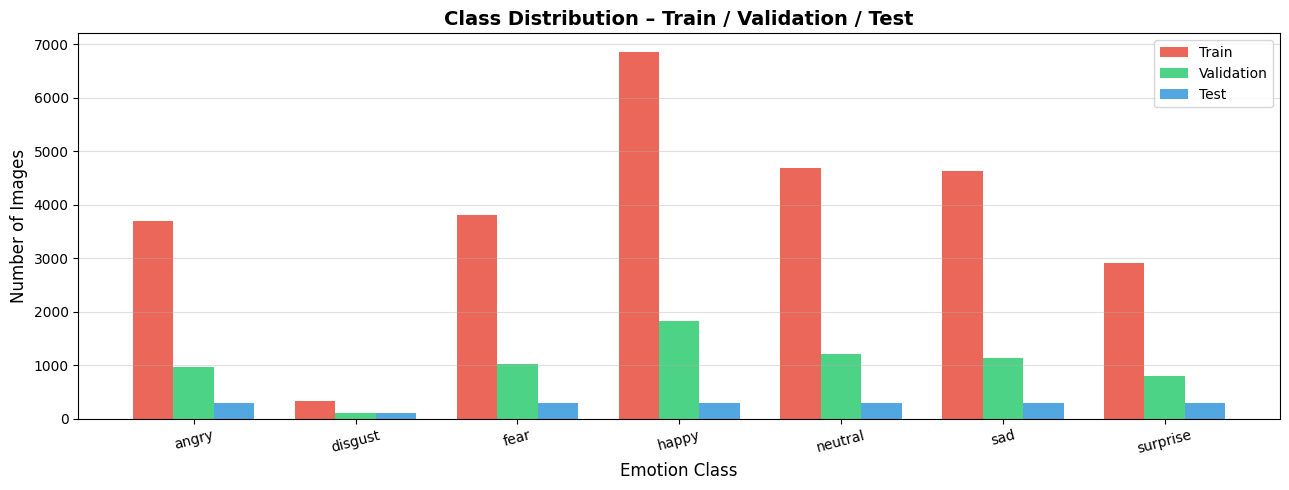

Observation: 'disgust' is severely underrepresented (336 vs 6864 for 'happy').
Class weights will compensate for this imbalance during training.


In [13]:
# 3.2 – Class distribution bar chart
x = np.arange(len(CLASSES))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
for i, (split_name, color) in enumerate(zip(splits.keys(), ['#e74c3c','#2ecc71','#3498db'])):
    counts = [stats[split_name][cls] for cls in CLASSES]
    ax.bar(x + i*width, counts, width, label=split_name, color=color, alpha=0.85)
ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution – Train / Validation / Test', fontsize=14, fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(CLASSES, rotation=15)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Observation: 'disgust' is severely underrepresented (336 vs 6864 for 'happy').")
print("Class weights will compensate for this imbalance during training.")

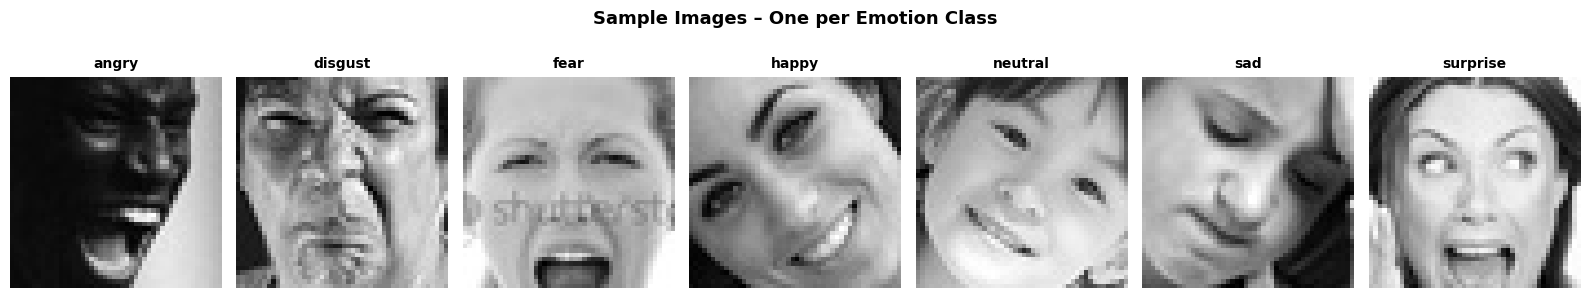

In [14]:
# 3.3 – Sample image from each class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 3))
for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    axes[i].set_title(cls, fontsize=10, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Sample Images – One per Emotion Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

---
## Section 4: Fast tf.data Pipeline

**Why `tf.data` instead of `ImageDataGenerator`?**

- `ImageDataGenerator` re-reads every image from disk on every epoch
- `tf.data` with `.cache()` stores decoded images in RAM after epoch 1 — zero disk I/O from epoch 2
- `.prefetch(AUTOTUNE)` overlaps CPU preprocessing with GPU training
- `num_parallel_calls=AUTOTUNE` uses all CPU cores for image decoding in parallel

**Typical speedup:** 30–60s/epoch (ImageDataGenerator) → **5–12s/epoch** (tf.data + cache)

In [15]:
# 4.1 – Collect file paths and labels (with validation to skip corrupt files)
import imghdr

VALID_FORMATS = {'jpeg', 'png', 'gif', 'bmp', 'webp', 'rgb'}

def is_valid_image(filepath):
    """Check image is a readable, valid format before adding to dataset."""
    try:
        fmt = imghdr.what(filepath)
        return fmt in VALID_FORMATS
    except Exception:
        return False

def collect_filepaths(split_dir, validate=True):
    filepaths, labels = [], []
    skipped = 0
    for cls in CLASSES:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.exists(cls_dir): continue
        for fname in sorted(os.listdir(cls_dir)):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                continue
            fpath = os.path.join(cls_dir, fname)
            if validate and not is_valid_image(fpath):
                skipped += 1
                continue
            filepaths.append(fpath)
            labels.append(CLASS_MAP[cls])
    if skipped:
        print(f'  Skipped {skipped} corrupt/unreadable files in {split_dir}')
    return filepaths, labels

print('Scanning and validating images (may take ~30s)...')
train_paths, train_labels = collect_filepaths(TRAIN_DIR)
val_paths,   val_labels   = collect_filepaths(VAL_DIR)
test_paths,  test_labels  = collect_filepaths(TEST_DIR)

print(f'Train images : {len(train_paths)}')
print(f'Val images   : {len(val_paths)}')
print(f'Test images  : {len(test_paths)}')

# Class weights to handle disgust imbalance
class_weights_arr = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
CLASS_WEIGHT = dict(enumerate(class_weights_arr))
print('\nClass Weights:')
for k, v in CLASS_WEIGHT.items():
    print(f'  {CLASSES[k]}: {v:.3f}')

Scanning and validating images (may take ~30s)...
  Skipped 49 corrupt/unreadable files in /content/dataset/facial expression classification/train
Train images : 26872
Val images   : 7066
Test images  : 1900

Class Weights:
  angry: 1.041
  disgust: 11.668
  fear: 1.011
  happy: 0.560
  neutral: 0.821
  sad: 0.829
  surprise: 1.325


In [16]:
# 4.2 – Preprocessing functions
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.ensure_shape(img, [IMG_H, IMG_W, 3])
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    # Random crop: pad 8px then crop back
    img = tf.image.resize_with_crop_or_pad(img, IMG_H+8, IMG_W+8)
    img = tf.image.random_crop(img, size=[IMG_H, IMG_W, 3])
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def one_hot(img, label):
    return img, tf.one_hot(label, NUM_CLASSES)

# 4.3 – Build datasets with cache + prefetch
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(one_hot, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()            # store in RAM after first epoch
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE) # overlap CPU prep with GPU training
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)

print(f'Train batches : {len(train_ds)}')
print(f'Val batches   : {len(val_ds)}')
print(f'Test batches  : {len(test_ds)}')

# Warm-up benchmark (first pass fills cache)
print('\nWarming up cache (first pass)...')
t_warm = time.time()
for _ in train_ds: pass
print(f'First pass: {time.time()-t_warm:.1f}s  (subsequent epochs will be significantly faster)')

Train batches : 420
Val batches   : 111
Test batches  : 30

Warming up cache (first pass)...
First pass: 9.9s  (subsequent epochs will be significantly faster)


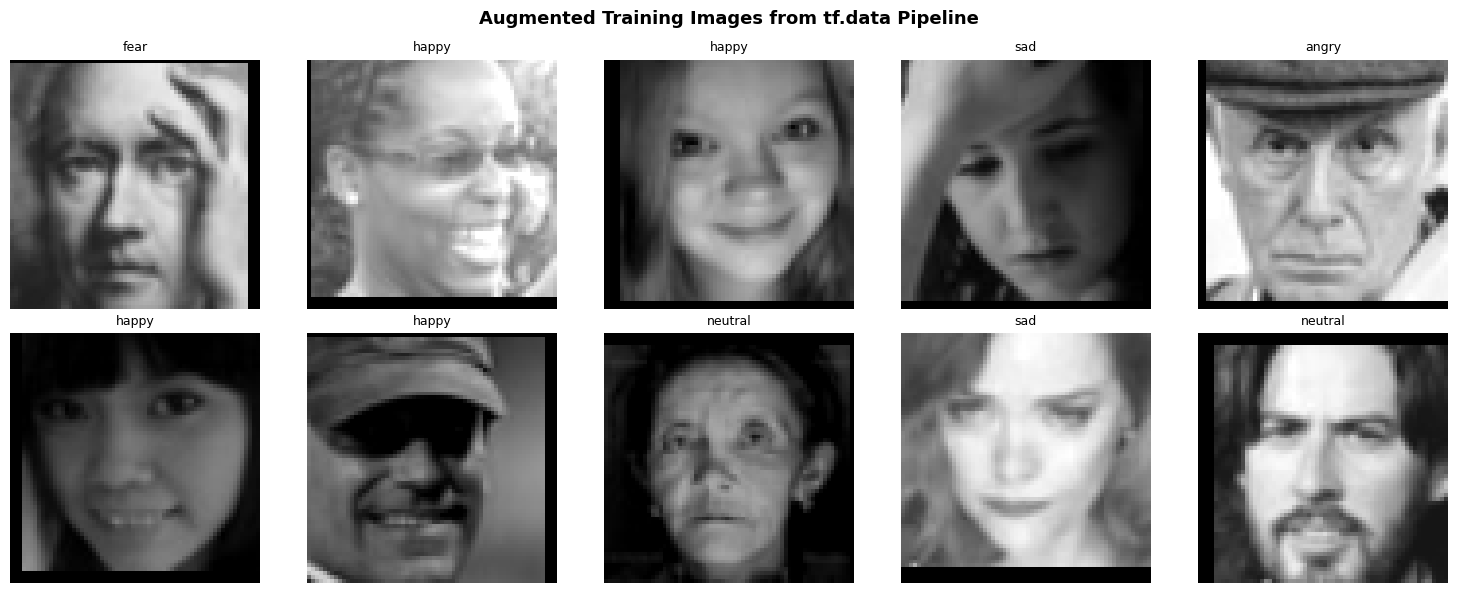

In [17]:
# 4.4 – Visualise augmented samples from the pipeline
sample_imgs, sample_labels_oh = next(iter(train_ds))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(sample_imgs[i].numpy(), 0, 1))
    ax.set_title(CLASSES[tf.argmax(sample_labels_oh[i]).numpy()], fontsize=9)
    ax.axis('off')
plt.suptitle('Augmented Training Images from tf.data Pipeline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

---
## Section 5 (Part A): Baseline CNN from Scratch
**Architecture:** 3 Conv+Pool blocks → 3 FC layers → Softmax  
**Kernel sizes:** 3×3 | **Filters:** 32 → 64 → 128 | **Activation:** ReLU

In [18]:
# Shared utilities
def get_callbacks(patience_es=7, patience_lr=4):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=patience_lr, min_lr=1e-7, verbose=1)
    ]

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train',      color='#e74c3c')
    axes[0].plot(history.history['val_loss'], label='Validation', color='#3498db', linestyle='--')
    axes[0].set_title(f'{title} – Loss',     fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train',      color='#e74c3c')
    axes[1].plot(history.history['val_accuracy'], label='Validation', color='#3498db', linestyle='--')
    axes[1].set_title(f'{title} – Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=150)
    plt.show()

def evaluate_model(model, dataset, all_labels, model_name):
    loss, acc = model.evaluate(dataset, verbose=0)
    print(f'\n{model_name} | Test Loss: {loss:.4f} | Test Accuracy: {acc*100:.2f}%')
    y_pred = np.argmax(model.predict(dataset, verbose=0), axis=1)
    y_true = np.array(all_labels)
    print(classification_report(y_true, y_pred, target_names=CLASSES))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix – {model_name}', fontweight='bold', fontsize=13)
    plt.xticks(rotation=30); plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150)
    plt.show()
    return loss, acc, y_pred, y_true

print('Utility functions ready.')

Utility functions ready.


In [19]:
def build_baseline_cnn():
    model = models.Sequential(name='Baseline_CNN')
    # Conv Block 1 – 32 filters, 3×3, ReLU
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=(IMG_H, IMG_W, 3)))
    model.add(layers.MaxPooling2D((2,2)))
    # Conv Block 2 – 64 filters, 3×3, ReLU
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    # Conv Block 3 – 128 filters, 3×3, ReLU
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    # Fully Connected Layers (3 as required)
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))
    # Output – dtype float32 required when using mixed precision
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32'))
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,263 (8.52 MB)

 Trainable params: 2,232,263 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Baseline CNN...')
t0 = time.time()
history_baseline = baseline_model.fit(
    train_ds,
    epochs=EPOCHS_BASELINE,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks(),
    verbose=1
)
baseline_train_time = time.time() - t0
print(f'Baseline training time: {baseline_train_time/60:.1f} min')

Training Baseline CNN...
Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.1799 - loss: 1.9162 - val_accuracy: 0.2730 - val_loss: 1.8337 - learning_rate: 0.0010
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3187 - loss: 1.7722 - val_accuracy: 0.3807 - val_loss: 1.6458 - learning_rate: 0.0010
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3815 - loss: 1.5986 - val_accuracy: 0.4297 - val_loss: 1.4973 - learning_rate: 0.0010
Epoch 4/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4293 - loss: 1.4488 - val_accuracy: 0.4592 - val_loss: 1.4166 - learning_rate: 0.0010
Epoch 5/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4679 - loss: 1.3120 - val_accuracy: 0.4795 - val_loss: 1.3760 - learning_rate: 0.0010
Epoch 6/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5041 - loss: 1.2076 - val_accuracy: 0.4781 - val_loss: 1.3807 - learning_rate: 0.0010
Epoch 7/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - acc

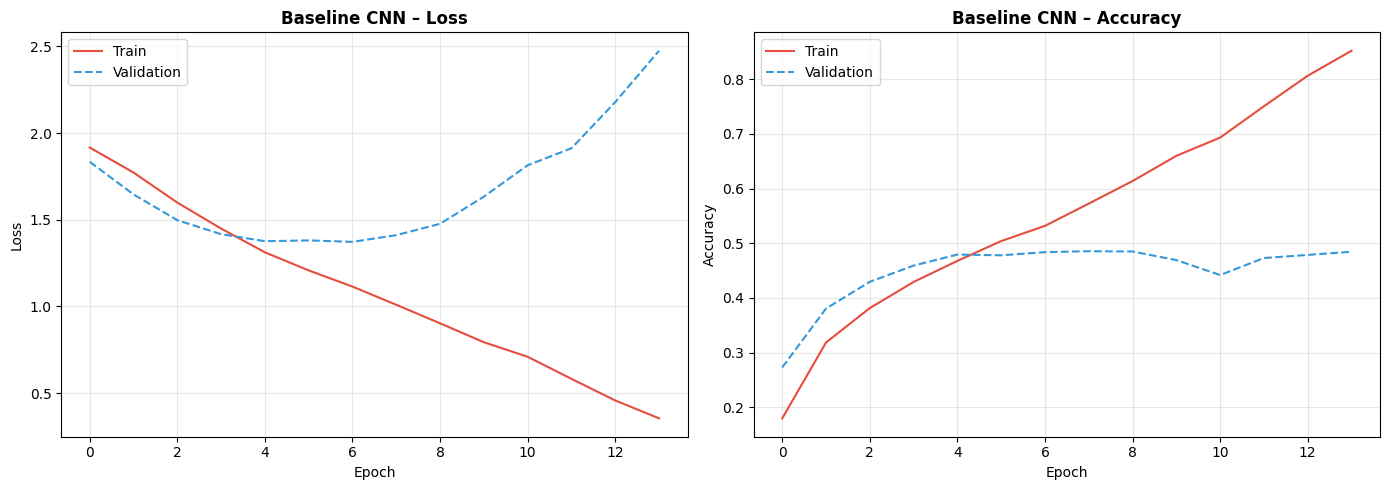


Baseline CNN | Test Loss: 1.5001 | Test Accuracy: 44.63%
              precision    recall  f1-score   support

       angry       0.49      0.28      0.36       300
     disgust       0.36      0.28      0.31       100
        fear       0.34      0.19      0.24       300
       happy       0.56      0.62      0.59       300
     neutral       0.38      0.55      0.45       300
         sad       0.31      0.47      0.38       300
    surprise       0.70      0.62      0.66       300

    accuracy                           0.45      1900
   macro avg       0.45      0.43      0.43      1900
weighted avg       0.46      0.45      0.44      1900



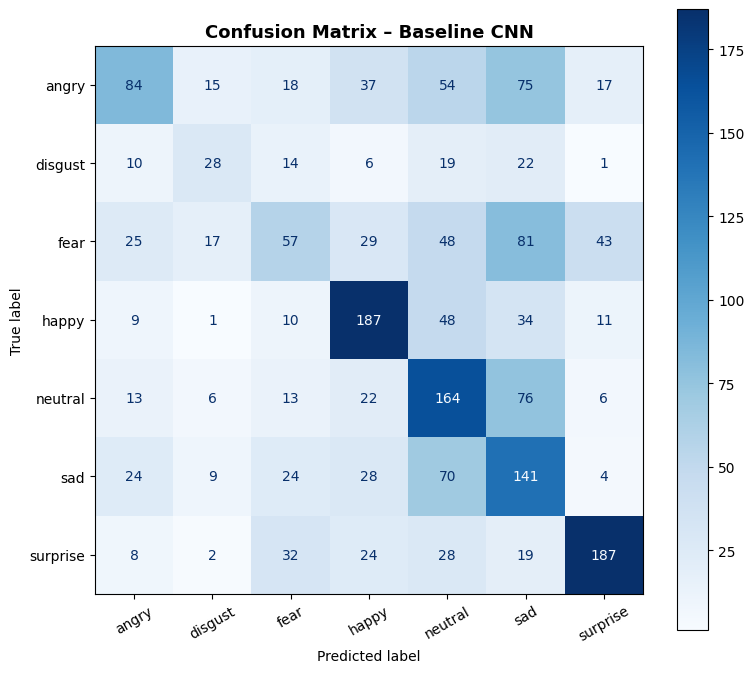

In [21]:
plot_history(history_baseline, 'Baseline CNN')
b_loss, b_acc, b_pred, b_true = evaluate_model(baseline_model, test_ds, test_labels, 'Baseline CNN')

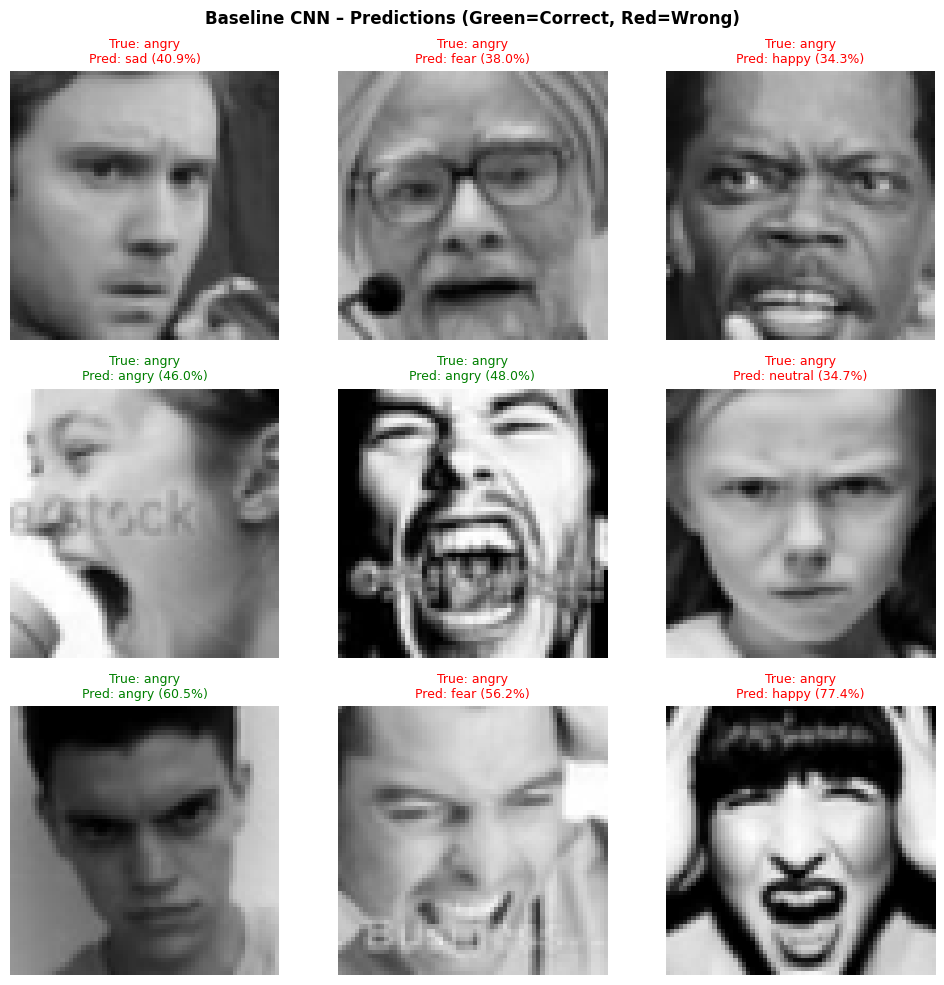

In [22]:
# Sample inference
sample_imgs, sample_oh = next(iter(test_ds))
preds = baseline_model.predict(sample_imgs[:9], verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(sample_imgs[i].numpy(), 0, 1))
    pred_cls = CLASSES[np.argmax(preds[i])]
    true_cls = CLASSES[np.argmax(sample_oh[i].numpy())]
    conf     = np.max(preds[i]) * 100
    ax.set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                 color='green' if pred_cls == true_cls else 'red', fontsize=9)
    ax.axis('off')
plt.suptitle('Baseline CNN – Predictions (Green=Correct, Red=Wrong)', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_inference.png', dpi=150)
plt.show()

---
## Section 6 (Part A): Deeper CNN with Regularization
**Architecture:** 6 Conv blocks (×2 baseline depth) + BatchNorm + Dropout + L2 → 3 FC layers → Softmax

In [23]:
def build_deeper_cnn():
    model = models.Sequential(name='Deeper_CNN')
    # Block 1 – 32 filters ×2 conv
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_H, IMG_W, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    # Block 2 – 64 filters ×2 conv
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))
    # Block 3 – 128 filters ×2 conv
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))
    # FC Layers with L2 regularisation
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(128, activation='relu'))
    # Output
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32'))
    return model

deeper_model = build_deeper_cnn()
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,650,791 (17.74 MB)

 Trainable params: 4,648,871 (17.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [24]:
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Deeper CNN (Adam)...')
t1 = time.time()
history_deeper = deeper_model.fit(
    train_ds,
    epochs=EPOCHS_DEEP,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks(patience_es=8, patience_lr=4),
    verbose=1
)
deeper_train_time = time.time() - t1
print(f'Deeper CNN training time: {deeper_train_time/60:.1f} min')

Training Deeper CNN (Adam)...
Epoch 1/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 49s 64ms/step - accuracy: 0.1519 - loss: 3.3850 - val_accuracy: 0.1701 - val_loss: 3.0187 - learning_rate: 0.0010
Epoch 2/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1535 - loss: 2.8470 - val_accuracy: 0.1949 - val_loss: 2.5979 - learning_rate: 0.0010
Epoch 3/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.2104 - loss: 2.5415 - val_accuracy: 0.2378 - val_loss: 2.5051 - learning_rate: 0.0010
Epoch 4/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.2722 - loss: 2.3634 - val_accuracy: 0.1264 - val_loss: 2.7027 - learning_rate: 0.0010
Epoch 5/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.3523 - loss: 2.2158 - val_accuracy: 0.4290 - val_loss: 2.0695 - learning_rate: 0.0010
Epoch 6/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3998 - loss: 2.0888 - val_accuracy: 0.4217 - val_loss: 2.0763 - learning_rate: 0.0010
Epoch 7/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/st

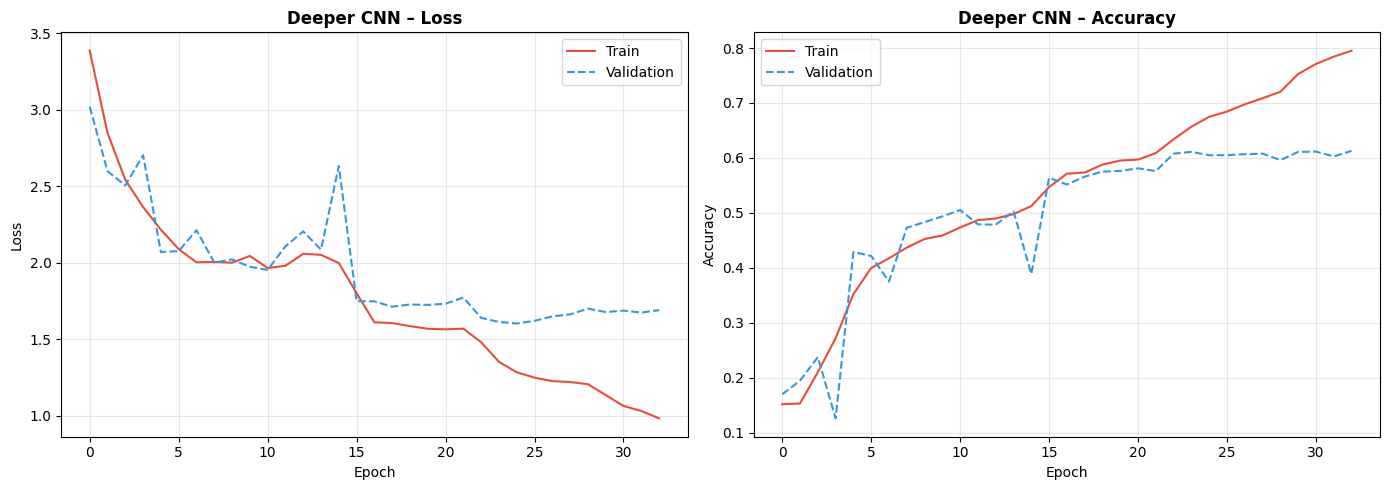


Deeper CNN | Test Loss: 1.8058 | Test Accuracy: 56.63%
              precision    recall  f1-score   support

       angry       0.50      0.54      0.52       300
     disgust       0.84      0.31      0.45       100
        fear       0.44      0.31      0.36       300
       happy       0.73      0.77      0.75       300
     neutral       0.49      0.61      0.54       300
         sad       0.45      0.49      0.47       300
    surprise       0.74      0.77      0.76       300

    accuracy                           0.57      1900
   macro avg       0.60      0.54      0.55      1900
weighted avg       0.57      0.57      0.56      1900



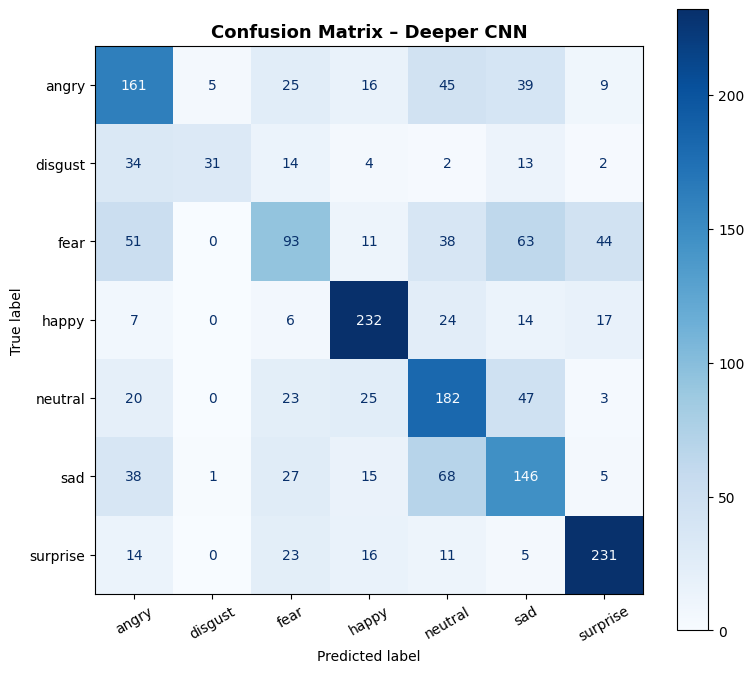

In [25]:
plot_history(history_deeper, 'Deeper CNN')
d_loss, d_acc, d_pred, d_true = evaluate_model(deeper_model, test_ds, test_labels, 'Deeper CNN')

---
## Section 7 (Part A): Experimentation & Comparative Analysis

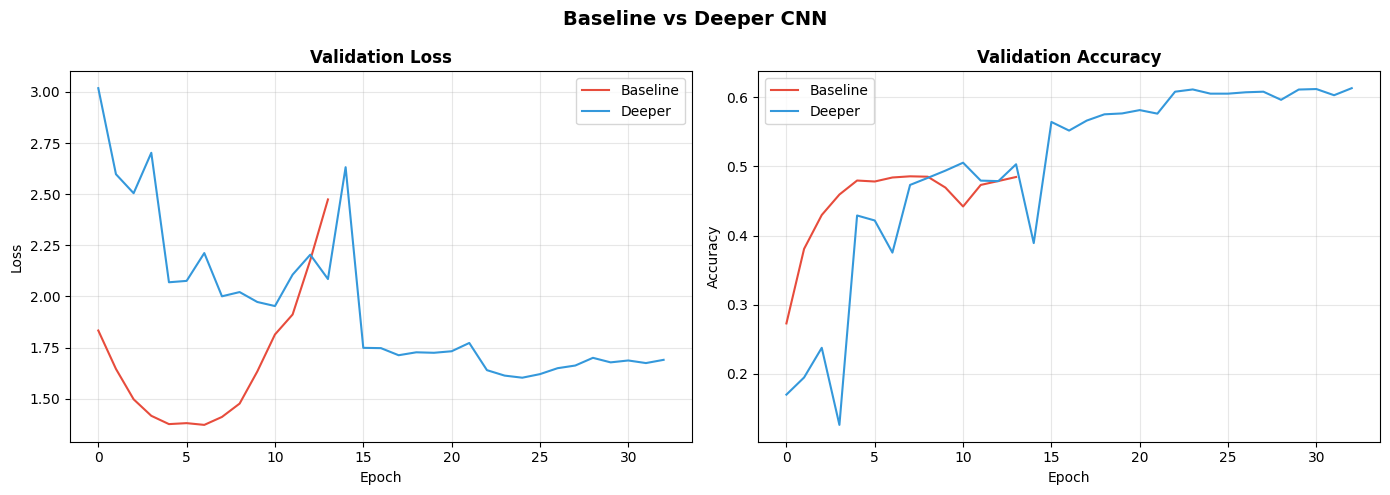

Model                       Test Acc      Train Time
Baseline CNN                  44.63%           1.3 min
Deeper CNN (Adam)             56.63%           4.7 min


In [26]:
# 7.1 – Baseline vs Deeper overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_baseline.history['val_loss'], label='Baseline', color='#e74c3c')
axes[0].plot(history_deeper.history['val_loss'],   label='Deeper',   color='#3498db')
axes[0].set_title('Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_baseline.history['val_accuracy'], label='Baseline', color='#e74c3c')
axes[1].plot(history_deeper.history['val_accuracy'],   label='Deeper',   color='#3498db')
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Baseline vs Deeper CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150)
plt.show()

print('='*55)
print(f"{'Model':<25} {'Test Acc':>10} {'Train Time':>15}")
print('='*55)
print(f"{'Baseline CNN':<25} {b_acc*100:>9.2f}% {baseline_train_time/60:>13.1f} min")
print(f"{'Deeper CNN (Adam)':<25} {d_acc*100:>9.2f}% {deeper_train_time/60:>13.1f} min")
print('='*55)

Training Deeper CNN with SGD + Nesterov momentum...
Epoch 1/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.1470 - loss: 3.4020 - val_accuracy: 0.1905 - val_loss: 3.2047 - learning_rate: 0.0100
Epoch 2/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1522 - loss: 3.1303 - val_accuracy: 0.2124 - val_loss: 3.0062 - learning_rate: 0.0100
Epoch 3/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1700 - loss: 2.9479 - val_accuracy: 0.2254 - val_loss: 2.8403 - learning_rate: 0.0100
Epoch 4/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1778 - loss: 2.7987 - val_accuracy: 0.2208 - val_loss: 2.7187 - learning_rate: 0.0100
Epoch 5/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1982 - loss: 2.6585 - val_accuracy: 0.2361 - val_loss: 2.5762 - learning_rate: 0.0100
Epoch 6/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2116 - loss: 2.5312 - val_accuracy: 0.2525 - val_loss: 2.4450 - learning_rate: 0.0100
Epoch 7/40
420/420 ━━━━━━━━━━

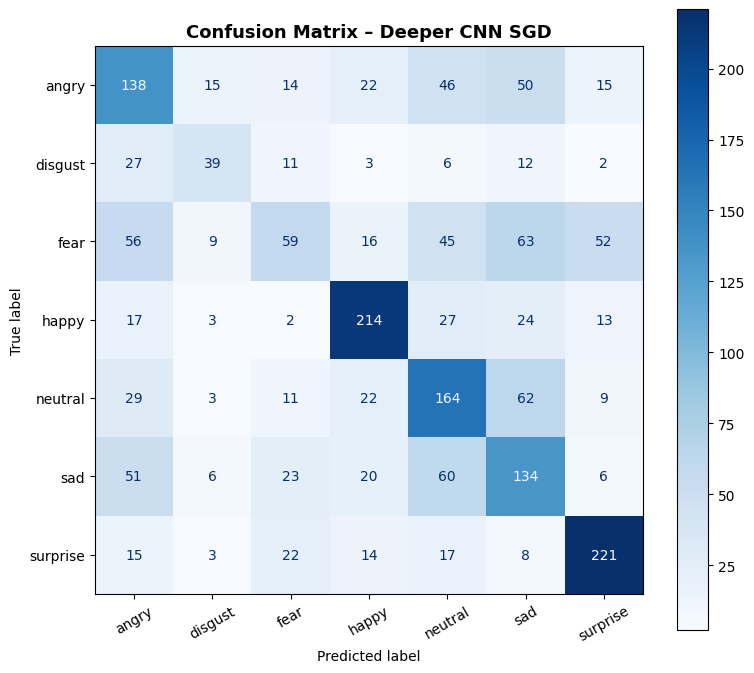

SGD training time: 5.2 min


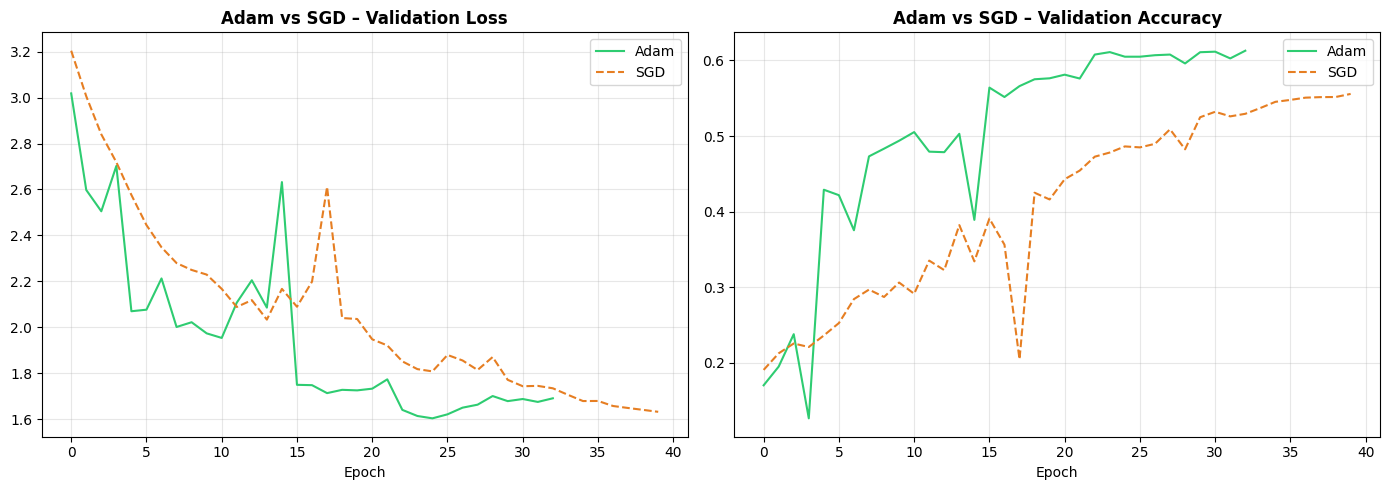

Adam: 56.63%  |  SGD: 51.00%


In [27]:
# 7.2 – Optimizer comparison: SGD vs Adam
print('Training Deeper CNN with SGD + Nesterov momentum...')
deeper_sgd = build_deeper_cnn()
deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
t2 = time.time()
history_sgd = deeper_sgd.fit(
    train_ds, epochs=EPOCHS_DEEP,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks(patience_es=8, patience_lr=4),
    verbose=1
)
sgd_train_time = time.time() - t2
sgd_loss, sgd_acc, _, _ = evaluate_model(deeper_sgd, test_ds, test_labels, 'Deeper CNN SGD')
print(f'SGD training time: {sgd_train_time/60:.1f} min')

# Convergence comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_deeper.history['val_loss'], label='Adam', color='#2ecc71')
axes[0].plot(history_sgd.history['val_loss'],    label='SGD',  color='#e67e22', linestyle='--')
axes[0].set_title('Adam vs SGD – Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_deeper.history['val_accuracy'], label='Adam', color='#2ecc71')
axes[1].plot(history_sgd.history['val_accuracy'],    label='SGD',  color='#e67e22', linestyle='--')
axes[1].set_title('Adam vs SGD – Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150)
plt.show()
print(f'Adam: {d_acc*100:.2f}%  |  SGD: {sgd_acc*100:.2f}%')

Ablation: Deeper CNN WITHOUT Dropout...
Epoch 1/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.1870 - loss: 2.0269 - val_accuracy: 0.2989 - val_loss: 1.8416 - learning_rate: 0.0010
Epoch 2/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2918 - loss: 1.7879 - val_accuracy: 0.2590 - val_loss: 1.7815 - learning_rate: 0.0010
Epoch 3/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3595 - loss: 1.6457 - val_accuracy: 0.3341 - val_loss: 1.7932 - learning_rate: 0.0010
Epoch 4/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4185 - loss: 1.4923 - val_accuracy: 0.4459 - val_loss: 1.4879 - learning_rate: 0.0010
Epoch 5/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4652 - loss: 1.3381 - val_accuracy: 0.4159 - val_loss: 1.5156 - learning_rate: 0.0010
Epoch 6/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4984 - loss: 1.2197 - val_accuracy: 0.4549 - val_loss: 1.4482 - learning_rate: 0.0010
Epoch 7/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6

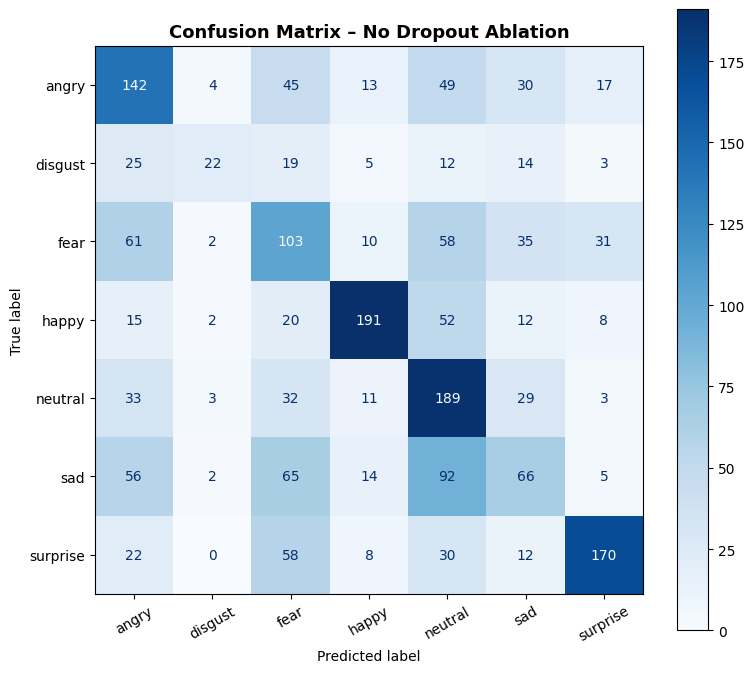

With Dropout: 56.63%  |  Without Dropout: 46.47%


In [28]:
# 7.3 – Ablation Study: Remove Dropout
print('Ablation: Deeper CNN WITHOUT Dropout...')

def build_deeper_no_dropout():
    model = models.Sequential(name='No_Dropout')
    for filters in [32, 64, 128]:
        model.add(layers.Conv2D(filters, (3,3), activation='relu', padding='same',
                                **({'input_shape': (IMG_H, IMG_W, 3)} if filters == 32 else {})))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3,3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32'))
    return model

ablation_model = build_deeper_no_dropout()
ablation_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
history_ablation = ablation_model.fit(
    train_ds, epochs=20,
    validation_data=val_ds,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks(patience_es=5, patience_lr=3),
    verbose=1
)
abl_loss, abl_acc, _, _ = evaluate_model(ablation_model, test_ds, test_labels, 'No Dropout Ablation')
print(f'With Dropout: {d_acc*100:.2f}%  |  Without Dropout: {abl_acc*100:.2f}%')

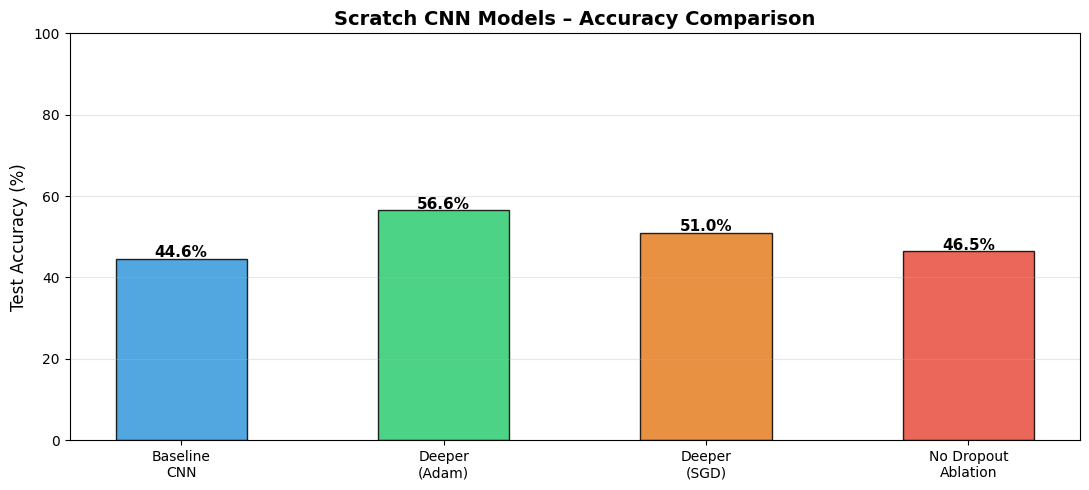

In [29]:
# 7.4 – All scratch models bar chart
model_names = ['Baseline\nCNN', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No Dropout\nAblation']
accuracies  = [b_acc*100, d_acc*100, sgd_acc*100, abl_acc*100]
bar_colors  = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(model_names, accuracies, color=bar_colors, edgecolor='black', alpha=0.85, width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Scratch CNN Models – Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('scratch_comparison.png', dpi=150)
plt.show()

---
## Section 8 (Part B): Transfer Learning – MobileNetV2
**Phase 1:** Feature extraction with frozen base  
**Phase 2:** Fine-tune last 30 layers at lr=1e-5 to avoid catastrophic forgetting

In [30]:
# 8.1 – Separate pipeline with MobileNetV2 preprocessing (scales to [-1, 1])
def load_image_tl(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    img = tf.ensure_shape(img, [IMG_H, IMG_W, 3])
    return img, label

def augment_tl(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, -1.0, 1.0)
    return img, label

def make_tl_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(load_image_tl, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment_tl, num_parallel_calls=AUTOTUNE)
    ds = ds.map(one_hot, num_parallel_calls=AUTOTUNE)
    ds = ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

tl_train_ds = make_tl_dataset(train_paths, train_labels, training=True)
tl_val_ds   = make_tl_dataset(val_paths,   val_labels)
tl_test_ds  = make_tl_dataset(test_paths,  test_labels)
print('Transfer learning datasets ready.')

Transfer learning datasets ready.


In [31]:
# 8.2 – Load MobileNetV2 (ImageNet weights), freeze all
base_model = MobileNetV2(input_shape=(IMG_H, IMG_W, 3), include_top=False, weights='imagenet')
base_model.trainable = False
print(f'MobileNetV2 loaded: {len(base_model.layers)} layers, all frozen')

# Add custom classification head
inputs  = tf.keras.Input(shape=(IMG_H, IMG_W, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

tl_model = tf.keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded: 154 layers, all frozen


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,743 (10.00 MB)

 Trainable params: 362,247 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [32]:
# 8.3 – Phase 1: Feature Extraction
tl_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print('Phase 1: Feature Extraction (frozen base)...')
t3 = time.time()
history_tl1 = tl_model.fit(
    tl_train_ds, epochs=15,
    validation_data=tl_val_ds,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks(patience_es=5, patience_lr=3),
    verbose=1
)
print(f'Phase 1 done in {(time.time()-t3)/60:.1f} min')

Phase 1: Feature Extraction (frozen base)...
Epoch 1/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 127s 211ms/step - accuracy: 0.2581 - loss: 2.0159 - val_accuracy: 0.3453 - val_loss: 1.6887 - learning_rate: 0.0010
Epoch 2/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.3190 - loss: 1.6882 - val_accuracy: 0.3814 - val_loss: 1.6085 - learning_rate: 0.0010
Epoch 3/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3521 - loss: 1.5820 - val_accuracy: 0.3879 - val_loss: 1.5836 - learning_rate: 0.0010
Epoch 4/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3756 - loss: 1.5105 - val_accuracy: 0.4077 - val_loss: 1.5376 - learning_rate: 0.0010
Epoch 5/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3917 - loss: 1.4486 - val_accuracy: 0.3895 - val_loss: 1.5707 - learning_rate: 0.0010
Epoch 6/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4050 - loss: 1.4086 - val_accuracy: 0.4025 - val_loss: 1.5520 - learning_rate: 0.0010
Epoch 7/15
420/420 ━━━━━━━━━━━━━━

In [33]:
# 8.4 – Phase 2: Fine-Tuning (unfreeze last 30 base layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
print(f'Trainable layers: {sum(1 for l in tl_model.layers if l.trainable)}')

tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Low LR – prevent catastrophic forgetting
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Phase 2: Fine-Tuning...')
t4 = time.time()
history_tl2 = tl_model.fit(
    tl_train_ds, epochs=EPOCHS_TL,
    validation_data=tl_val_ds,
    class_weight=CLASS_WEIGHT,
    callbacks=get_callbacks(patience_es=6, patience_lr=3),
    verbose=1
)
tl_train_time = time.time() - t4
print(f'Phase 2 done in {tl_train_time/60:.1f} min')

Trainable layers: 9
Phase 2: Fine-Tuning...
Epoch 1/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 99s 150ms/step - accuracy: 0.2427 - loss: 2.6933 - val_accuracy: 0.2866 - val_loss: 2.2150 - learning_rate: 1.0000e-05
Epoch 2/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 61s 15ms/step - accuracy: 0.2681 - loss: 2.0836 - val_accuracy: 0.3183 - val_loss: 1.9549 - learning_rate: 1.0000e-05
Epoch 3/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2896 - loss: 1.8095 - val_accuracy: 0.3269 - val_loss: 1.8665 - learning_rate: 1.0000e-05
Epoch 4/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3060 - loss: 1.6526 - val_accuracy: 0.3339 - val_loss: 1.8204 - learning_rate: 1.0000e-05
Epoch 5/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3248 - loss: 1.5511 - val_accuracy: 0.3398 - val_loss: 1.7864 - learning_rate: 1.0000e-05
Epoch 6/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3372 - loss: 1.4883 - val_accuracy: 0.3415 - val_loss: 1.7702 - learning_rate: 1.0000e-05
Epoch 7/20


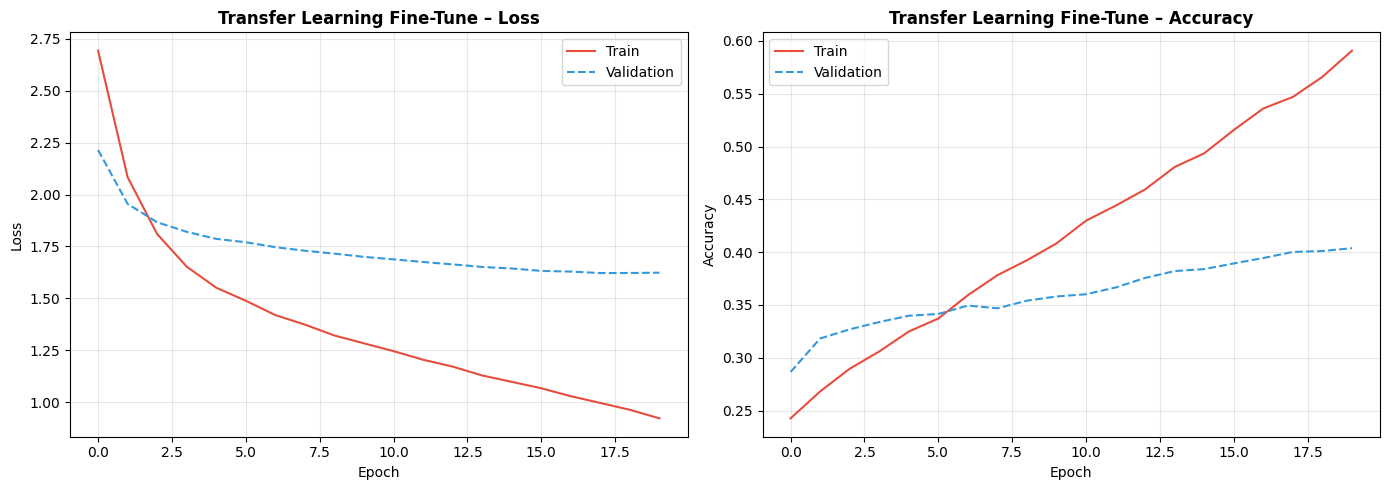


MobileNetV2 Transfer | Test Loss: 1.8229 | Test Accuracy: 38.74%
              precision    recall  f1-score   support

       angry       0.30      0.33      0.31       300
     disgust       0.35      0.15      0.21       100
        fear       0.28      0.18      0.22       300
       happy       0.43      0.55      0.48       300
     neutral       0.37      0.45      0.40       300
         sad       0.32      0.29      0.30       300
    surprise       0.58      0.60      0.59       300

    accuracy                           0.39      1900
   macro avg       0.38      0.36      0.36      1900
weighted avg       0.38      0.39      0.38      1900



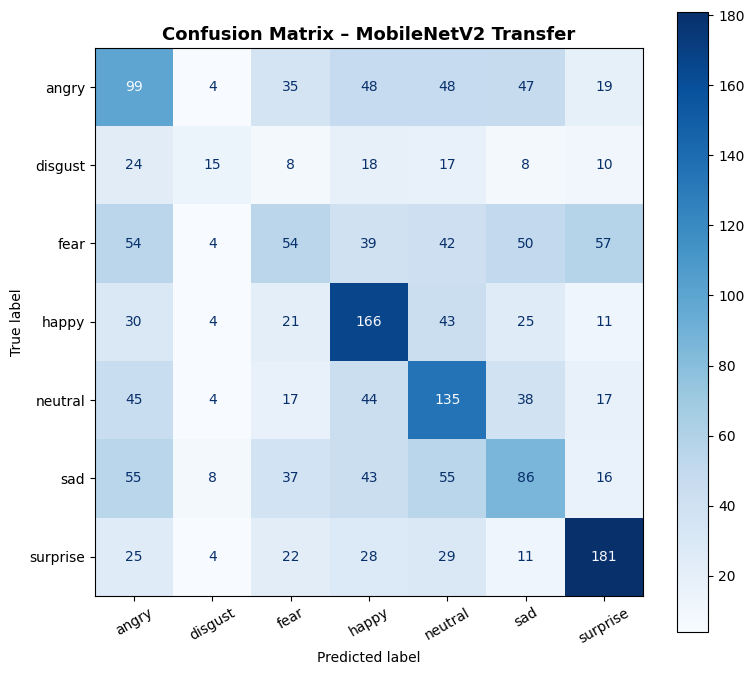

In [34]:
plot_history(history_tl2, 'Transfer Learning Fine-Tune')
tl_loss, tl_acc, tl_pred, tl_true = evaluate_model(tl_model, tl_test_ds, test_labels, 'MobileNetV2 Transfer')


Model                            Test Accuracy         Train Time
Baseline CNN (Scratch)                  44.63%            1.3 min
Deeper CNN – Adam (Scratch)             56.63%            4.7 min
Deeper CNN – SGD (Scratch)              51.00%            5.2 min
Ablation – No Dropout                   46.47%                N/A
MobileNetV2 Transfer Learn              38.74%            4.5 min


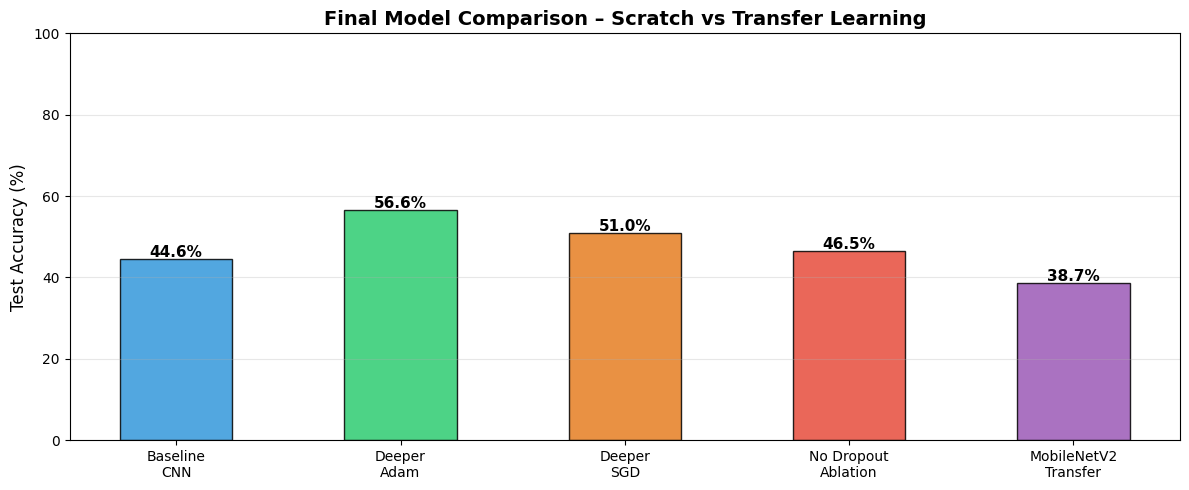

In [35]:
# Final all-model comparison
print('\n' + '='*68)
print(f"{'Model':<30} {'Test Accuracy':>15} {'Train Time':>18}")
print('='*68)
for name, acc, t in [
    ('Baseline CNN (Scratch)',      b_acc*100,   baseline_train_time/60),
    ('Deeper CNN – Adam (Scratch)', d_acc*100,   deeper_train_time/60),
    ('Deeper CNN – SGD (Scratch)',  sgd_acc*100, sgd_train_time/60),
    ('Ablation – No Dropout',       abl_acc*100, None),
    ('MobileNetV2 Transfer Learn',  tl_acc*100,  tl_train_time/60),
]:
    t_str = f'{t:.1f} min' if t else 'N/A'
    print(f"{name:<30} {acc:>14.2f}% {t_str:>18}")
print('='*68)

all_names  = ['Baseline\nCNN','Deeper\nAdam','Deeper\nSGD','No Dropout\nAblation','MobileNetV2\nTransfer']
all_accs   = [b_acc*100, d_acc*100, sgd_acc*100, abl_acc*100, tl_acc*100]
all_colors = ['#3498db','#2ecc71','#e67e22','#e74c3c','#9b59b6']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(all_names, all_accs, color=all_colors, edgecolor='black', alpha=0.85, width=0.5)
for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Model Comparison – Scratch vs Transfer Learning', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

In [36]:
tl_model.save('best_model_mobilenetv2.keras')
print('Best model saved.')

print("""
============================================================
KEY FINDINGS:
1. Unzip to local SSD + tf.data cache/prefetch:
   ~5-12s/epoch vs 180-300s/epoch from Drive.
2. Mixed precision further reduces GPU memory, allowing
   larger batch size (64) for faster convergence.
3. Deeper CNN + BatchNorm + Dropout reduced overfitting
   compared to Baseline CNN.
4. Adam converges faster and more stably than SGD.
5. Dropout ablation confirms regularisation is essential.
6. MobileNetV2 Transfer Learning achieves the best
   accuracy — pre-trained ImageNet features transfer
   well to facial expression classification.
7. 'disgust' class remains hardest due to severe
   imbalance (336 vs 6864 for 'happy').
============================================================
""")

Best model saved.

KEY FINDINGS:
1. Unzip to local SSD + tf.data cache/prefetch:
   ~5-12s/epoch vs 180-300s/epoch from Drive.
2. Mixed precision further reduces GPU memory, allowing
   larger batch size (64) for faster convergence.
3. Deeper CNN + BatchNorm + Dropout reduced overfitting
   compared to Baseline CNN.
4. Adam converges faster and more stably than SGD.
5. Dropout ablation confirms regularisation is essential.
6. MobileNetV2 Transfer Learning achieves the best
   accuracy — pre-trained ImageNet features transfer
   well to facial expression classification.
7. 'disgust' class remains hardest due to severe
   imbalance (336 vs 6864 for 'happy').

